# LMC-Synth coverage with oracle-latent SARIMA and end-to-end seasonal VAR-CSS

## Abstract

This experiment adds explicit seasonal lag structure to both TimePFN LMC-Synth access modes. The oracle-latent path fits a seasonal scalar model to each retained latent function before applying the true mixing matrix. The end-to-end path fits a seasonal vector model directly to the observed channels. Oracle periods retained by the generator and periods selected from training spectra are evaluated and labeled separately. Mechanisms, trajectories, seeds, metrics, thresholds, and the coverage decision remain aligned with the AR/VAR and ARIMA/VARMA experiments.

In [1]:
from __future__ import annotations

import json
import platform
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src"))

from tsfmxai.baselines import fit_pooled_arma, one_step_nmse, simulate_pooled_arma
from tsfmxai.evaluation import (
    DEFAULT_THRESHOLDS,
    channel_metrics,
    distribution_metrics,
    dominant_periods,
    passes_channel_coverage,
    passes_coverage,
    violation_score,
)
from tsfmxai.generators import (
    draw_retained_kernel_case,
    draw_retained_lmc_case,
    retained_kernel_cases,
    retained_lmc_mechanisms,
)

GLOBAL_SEED = 20260930
LENGTH = 1024
N_TRAIN = 16
N_TEST = 16
RIDGE = 1e-5
CSS_ITERATIONS = 4
MAX_ACF_LAG = 64
THRESHOLDS = dict(DEFAULT_THRESHOLDS)
CROSS_CORR_THRESHOLD = 0.10


MODEL_SHAPES = [((1, 0, 1), (1, 0, 0)), ((2, 0, 1), (1, 0, 1))]
SELECTED_PERIOD_COUNT = 2
MAX_SELECTED_PERIOD = 256

def fit_latent_set(data, periods, order, seasonal_shape):
    fits = []
    for latent, period in enumerate(periods):
        fits.append(fit_pooled_arma(data["train_latents"][:, latent, :], order=order,
                                    seasonal_order=seasonal_shape + (int(period),),
                                    ridge=RIDGE, css_iterations=CSS_ITERATIONS))
    return fits

print(f"Seasonal shapes: {MODEL_SHAPES}")

Seasonal shapes: [((1, 0, 1), (1, 0, 0)), ((2, 0, 1), (1, 0, 1))]


The oracle-latent model may use a different seasonal period for each latent. The end-to-end seasonal vector model uses one shared period per candidate because it receives only the observed channels.

In [2]:
MECHANISMS, BANK, LATENT_FACTORS = retained_lmc_mechanisms(global_seed=GLOBAL_SEED, length=LENGTH)
assert len(MECHANISMS) == 11 and len(BANK) == 33
display(pd.DataFrame([{key: mechanism[key] for key in ["id", "latent_ids", "latent_periods"]}
                      for mechanism in MECHANISMS]))

,id,latent_ids,latent_periods
0,lmc_01,"[periodic_01_p24, periodic_02_p48, periodic_03...","[[24], [48], [96]]"
1,lmc_02,"[periodic_04_p168, periodic_05_p336, periodic_...","[[168], [336], [672]]"
2,lmc_03,"[periodic_07_p7, periodic_08_p14, periodic_09_...","[[7], [14], [30]]"
3,lmc_04,"[periodic_10_p60, periodic_11_p365, periodic_1...","[[60], [365], [730]]"
4,lmc_05,"[periodic_13_p4, periodic_14_p26, periodic_15_...","[[4], [26], [52]]"
5,lmc_06,"[periodic_16_p4, periodic_17_p6, periodic_18_p12]","[[4], [6], [12]]"
6,lmc_07,"[periodic_19_p4, periodic_20_p40, periodic_21_...","[[4], [40], [10]]"
7,lmc_08,"[linear_sigma0, linear_sigma1, linear_sigma10]","[[], [], []]"
8,lmc_09,"[rbf_scale0.1, rbf_scale1, rbf_scale10]","[[], [], []]"
9,lmc_10,"[rq_alpha0.1, rq_alpha1, rq_alpha10]","[[], [], []]"


All 33 latent bank entries occur once across the eleven retained mechanisms. Empty latent period lists identify nonperiodic kernels, for which both period-selection modes fall back to training data.

In [3]:
rows = []
reference_series = {}
for mechanism_index, mechanism in enumerate(MECHANISMS):
    data = draw_retained_lmc_case(mechanism, LATENT_FACTORS, mechanism_index=mechanism_index,
                                  global_seed=GLOBAL_SEED, n_train=N_TRAIN, n_test=N_TEST)
    reference_series[mechanism["id"]] = data["test_channels"][0].copy()
    selected_latent_periods = [dominant_periods(data["train_latents"][:, latent, :], count=1,
                                                maximum=MAX_SELECTED_PERIOD)[0] for latent in range(3)]
    oracle_latent_periods = [periods[0] if periods else selected_latent_periods[latent]
                             for latent, periods in enumerate(mechanism["latent_periods"])]
    latent_period_sets = [("data_selected", selected_latent_periods),
                          ("oracle", oracle_latent_periods)]
    observed_periods = [("data_selected", period) for period in dominant_periods(
        data["train_channels"], count=SELECTED_PERIOD_COUNT, maximum=MAX_SELECTED_PERIOD)]
    observed_periods += [("oracle", period) for period in sorted({p for values in mechanism["latent_periods"] for p in values})]
    observed_periods = list(dict.fromkeys(observed_periods))

    for shape_index, (order, seasonal_shape) in enumerate(MODEL_SHAPES):
        for source_index, (period_source, periods) in enumerate(latent_period_sets):
            try:
                latent_fits = fit_latent_set(data, periods, order, seasonal_shape)
                start = max(fit.start for fit in latent_fits)
                if start >= LENGTH - MAX_ACF_LAG - 1:
                    raise ValueError(f"initialization prefix {start} leaves insufficient evaluation data")
                generated_latents = np.stack([
                    simulate_pooled_arma(
                        fit, data["test_latents"][:, latent, :fit.start], length=LENGTH,
                        rng=np.random.default_rng(GLOBAL_SEED + 8_000_000 + 10000 * mechanism_index
                                                  + 1000 * shape_index + 100 * source_index + latent),
                    ) for latent, fit in enumerate(latent_fits)
                ], axis=1)
                raw_latents = generated_latents * data["latent_scales"][None, :, None] + data["latent_means"][None, :, None]
                raw_channels = np.einsum("cq,nqt->ntc", mechanism["mixing"], raw_latents)
                generated = (raw_channels - data["channel_means"]) / data["channel_scales"]
                metrics = channel_metrics(data["test_channels"], generated, start, max_acf_lag=MAX_ACF_LAG)
                forecast_nmse = float(np.mean([one_step_nmse(fit, data["test_latents"][:, latent, :])
                                               for latent, fit in enumerate(latent_fits)])); error = None
            except Exception as exc:
                metrics = {**{key: float("inf") for key in THRESHOLDS}, "cross_corr_frobenius": float("inf")}
                forecast_nmse = float("inf"); error = f"{type(exc).__name__}: {exc}"
            rows.append({"mechanism": mechanism["id"], "latent_ids": ", ".join(mechanism["latent_ids"]),
                         "model": "oracle_latent_SARIMA", "configuration": f"{period_source}:{order}x{seasonal_shape}",
                         "order": int(max(max(periods), order[0], order[2])), "period_source": period_source,
                         "seasonal_period": ",".join(map(str, periods)), "forecast_nmse": forecast_nmse,
                         **metrics, "well_covered": passes_channel_coverage(
                             metrics, thresholds=THRESHOLDS,
                             cross_correlation_threshold=CROSS_CORR_THRESHOLD), "error": error})

        for candidate_index, (period_source, period) in enumerate(observed_periods):
            try:
                fit = fit_pooled_arma(data["train_channels"], order=order,
                                      seasonal_order=seasonal_shape + (int(period),),
                                      ridge=RIDGE, css_iterations=CSS_ITERATIONS)
                if fit.start >= LENGTH - MAX_ACF_LAG - 1:
                    raise ValueError(f"initialization prefix {fit.start} leaves insufficient evaluation data")
                generated = simulate_pooled_arma(
                    fit, data["test_channels"][:, :fit.start], length=LENGTH,
                    rng=np.random.default_rng(GLOBAL_SEED + 9_000_000 + 10000 * mechanism_index
                                              + 1000 * shape_index + candidate_index),
                )
                metrics = channel_metrics(data["test_channels"], generated, fit.start,
                                          max_acf_lag=MAX_ACF_LAG)
                forecast_nmse = one_step_nmse(fit, data["test_channels"]); error = None
            except Exception as exc:
                metrics = {**{key: float("inf") for key in THRESHOLDS}, "cross_corr_frobenius": float("inf")}
                forecast_nmse = float("inf"); error = f"{type(exc).__name__}: {exc}"
            rows.append({"mechanism": mechanism["id"], "latent_ids": ", ".join(mechanism["latent_ids"]),
                         "model": "end_to_end_seasonal_VAR", "configuration": f"{period_source}:{order}x{seasonal_shape}@{period}",
                         "order": int(max(period, order[0], order[2])), "period_source": period_source,
                         "seasonal_period": str(period), "forecast_nmse": forecast_nmse,
                         **metrics, "well_covered": passes_channel_coverage(
                             metrics, thresholds=THRESHOLDS,
                             cross_correlation_threshold=CROSS_CORR_THRESHOLD), "error": error})

results = pd.DataFrame(rows)
results["violation_score"] = results.apply(
    lambda row: violation_score(row, thresholds=THRESHOLDS,
                                cross_correlation_threshold=CROSS_CORR_THRESHOLD), axis=1)
best = (results.sort_values(["mechanism", "model", "violation_score", "forecast_nmse", "configuration"])
        .groupby(["mechanism", "model"], as_index=False).first())
status = results.groupby(["mechanism", "model"])["well_covered"].any().rename("well_covered_any_order").reset_index()
best = best.merge(status, on=["mechanism", "model"])
source_summary = (results.groupby(["model", "period_source", "mechanism"])["well_covered"].any().reset_index()
                  .groupby(["model", "period_source"])["well_covered"].mean().unstack(0))
display(best[["mechanism", "model", "configuration", "period_source", "seasonal_period",
              "well_covered_any_order", "acf_mae", "psd_jsd", "abs_log_variance_ratio",
              "standardized_wasserstein", "cross_corr_frobenius"]].round(4))

C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:153: RuntimeWarning: overflow encountered in matmul
  prediction += residuals[:, time_index - lag] @ coefficient
C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:153: RuntimeWarning: invalid value encountered in matmul
  prediction += residuals[:, time_index - lag] @ coefficient
C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:196: RuntimeWarning: overflow encountered in square
  return float(np.mean((target - predicted) ** 2) / (np.var(target) + 1e-12))
C:\Users\mateu\repos\tsfmxai\.venv\Lib\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


,mechanism,model,configuration,period_source,seasonal_period,well_covered_any_order,acf_mae,psd_jsd,abs_log_variance_ratio,standardized_wasserstein,cross_corr_frobenius
0,lmc_01,end_to_end_seasonal_VAR,"data_selected:(2, 0, 1)x(1, 0, 1)@93",data_selected,93,True,0.0004,0.0000,0.0001,1.300000e-03,0.0005
1,lmc_01,oracle_latent_SARIMA,"data_selected:(1, 0, 1)x(1, 0, 0)",data_selected,"24,49,93",False,0.7524,0.6496,34.0286,6.069939e+07,0.3222
2,lmc_02,end_to_end_seasonal_VAR,"oracle:(2, 0, 1)x(1, 0, 1)@672",oracle,672,True,0.0000,0.0000,0.0000,2.000000e-04,0.0000
3,lmc_02,oracle_latent_SARIMA,"oracle:(2, 0, 1)x(1, 0, 1)",oracle,"168,336,672",True,0.0000,0.0000,0.0000,2.000000e-04,0.0000
4,lmc_03,end_to_end_seasonal_VAR,"data_selected:(1, 0, 1)x(1, 0, 0)@7",data_selected,7,False,0.3944,0.3168,0.5496,2.956000e-01,0.0969
5,lmc_03,oracle_latent_SARIMA,"oracle:(1, 0, 1)x(1, 0, 0)",oracle,"7,14,30",False,0.9563,0.6925,33.5472,2.000928e+07,0.2812
6,lmc_04,end_to_end_seasonal_VAR,"data_selected:(2, 0, 1)x(1, 0, 1)@60",data_selected,60,False,0.0804,0.0279,0.5537,1.838000e-01,0.0632
7,lmc_04,oracle_latent_SARIMA,"data_selected:(1, 0, 1)x(1, 0, 0)",data_selected,"60,171,256",False,1.0036,0.6926,35.3412,4.687862e+07,0.1647
8,lmc_05,end_to_end_seasonal_VAR,"data_selected:(2, 0, 1)x(1, 0, 1)@51",data_selected,51,True,0.0890,0.0098,0.0043,3.190000e-02,0.0009
9,lmc_05,oracle_latent_SARIMA,"data_selected:(1, 0, 1)x(1, 0, 0)",data_selected,"4,26,51",False,0.7899,0.5978,24.6279,5.871870e+05,0.3855


The oracle path separates temporal seasonal approximation from the retained LMC mixing. The end-to-end path evaluates the complete observed process and must preserve both channel-level distributions and cross-channel correlations.

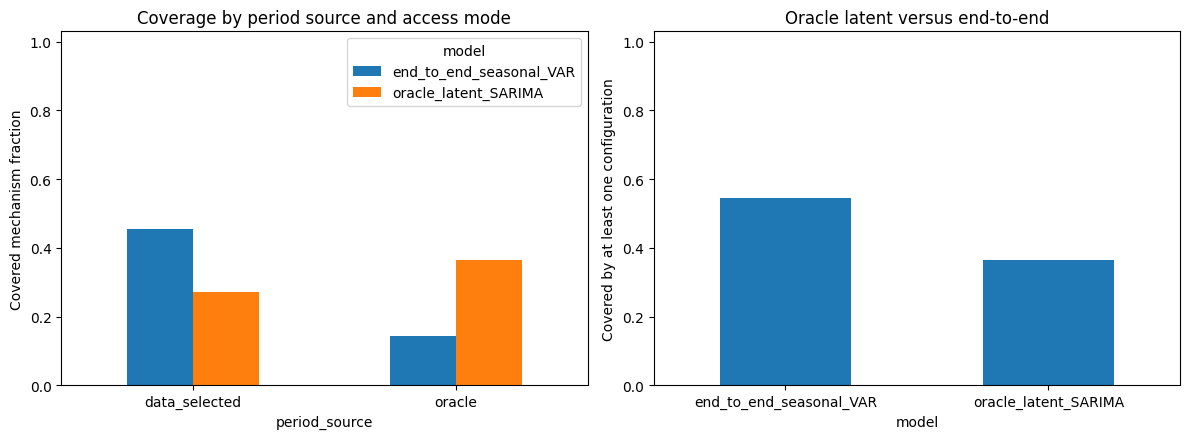

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
source_summary.plot.bar(ax=axes[0], rot=0); axes[0].set_ylim(0, 1.03)
axes[0].set_ylabel("Covered mechanism fraction"); axes[0].set_title("Coverage by period source and access mode")
best.groupby("model")["well_covered_any_order"].mean().plot.bar(ax=axes[1], rot=0)
axes[1].set_ylim(0, 1.03); axes[1].set_ylabel("Covered by at least one configuration")
axes[1].set_title("Oracle latent versus end-to-end")
fig.tight_layout(); plt.show()

The first plot exposes the effect of supplying generator periods. The second summarizes whether any seasonal configuration covers each retained mechanism in each access mode.

In [5]:
covered_pairs = best.loc[best.well_covered_any_order, ["mechanism", "model"]]
failed_pairs = best.loc[~best.well_covered_any_order, ["mechanism", "model"]]
covered_functions = [f"{row.mechanism} [{row.model}]" for row in covered_pairs.itertuples()]
not_covered_functions = [f"{row.mechanism} [{row.model}]" for row in failed_pairs.itertuples()]
diagnostic_series = []
for row in failed_pairs.itertuples():
    mode = "oracle_latent" if "oracle_latent" in row.model else "end_to_end"
    diagnostic_series.append({"benchmark": "lmc_synth", "mechanism": row.mechanism,
                              "evaluation_mode": mode,
                              "values": reference_series[row.mechanism].tolist()})
print(f"WELL COVERED ({len(covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in covered_functions) or "  (none)")
print(f"\nNOT WELL COVERED ({len(not_covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in not_covered_functions) or "  (none)")
display(best[["mechanism", "latent_ids", "model", "configuration", "period_source",
              "seasonal_period", "well_covered_any_order"]])

WELL COVERED (10/22):
  - lmc_01 [end_to_end_seasonal_VAR]
  - lmc_02 [end_to_end_seasonal_VAR]
  - lmc_02 [oracle_latent_SARIMA]
  - lmc_05 [end_to_end_seasonal_VAR]
  - lmc_08 [end_to_end_seasonal_VAR]
  - lmc_08 [oracle_latent_SARIMA]
  - lmc_10 [end_to_end_seasonal_VAR]
  - lmc_10 [oracle_latent_SARIMA]
  - lmc_11 [end_to_end_seasonal_VAR]
  - lmc_11 [oracle_latent_SARIMA]

NOT WELL COVERED (12/22):
  - lmc_01 [oracle_latent_SARIMA]
  - lmc_03 [end_to_end_seasonal_VAR]
  - lmc_03 [oracle_latent_SARIMA]
  - lmc_04 [end_to_end_seasonal_VAR]
  - lmc_04 [oracle_latent_SARIMA]
  - lmc_05 [oracle_latent_SARIMA]
  - lmc_06 [end_to_end_seasonal_VAR]
  - lmc_06 [oracle_latent_SARIMA]
  - lmc_07 [end_to_end_seasonal_VAR]
  - lmc_07 [oracle_latent_SARIMA]
  - lmc_09 [end_to_end_seasonal_VAR]
  - lmc_09 [oracle_latent_SARIMA]


,mechanism,latent_ids,model,configuration,period_source,seasonal_period,well_covered_any_order
0,lmc_01,"periodic_01_p24, periodic_02_p48, periodic_03_p96",end_to_end_seasonal_VAR,"data_selected:(2, 0, 1)x(1, 0, 1)@93",data_selected,93,True
1,lmc_01,"periodic_01_p24, periodic_02_p48, periodic_03_p96",oracle_latent_SARIMA,"data_selected:(1, 0, 1)x(1, 0, 0)",data_selected,"24,49,93",False
2,lmc_02,"periodic_04_p168, periodic_05_p336, periodic_0...",end_to_end_seasonal_VAR,"oracle:(2, 0, 1)x(1, 0, 1)@672",oracle,672,True
3,lmc_02,"periodic_04_p168, periodic_05_p336, periodic_0...",oracle_latent_SARIMA,"oracle:(2, 0, 1)x(1, 0, 1)",oracle,"168,336,672",True
4,lmc_03,"periodic_07_p7, periodic_08_p14, periodic_09_p30",end_to_end_seasonal_VAR,"data_selected:(1, 0, 1)x(1, 0, 0)@7",data_selected,7,False
5,lmc_03,"periodic_07_p7, periodic_08_p14, periodic_09_p30",oracle_latent_SARIMA,"oracle:(1, 0, 1)x(1, 0, 0)",oracle,"7,14,30",False
6,lmc_04,"periodic_10_p60, periodic_11_p365, periodic_12...",end_to_end_seasonal_VAR,"data_selected:(2, 0, 1)x(1, 0, 1)@60",data_selected,60,False
7,lmc_04,"periodic_10_p60, periodic_11_p365, periodic_12...",oracle_latent_SARIMA,"data_selected:(1, 0, 1)x(1, 0, 0)",data_selected,"60,171,256",False
8,lmc_05,"periodic_13_p4, periodic_14_p26, periodic_15_p52",end_to_end_seasonal_VAR,"data_selected:(2, 0, 1)x(1, 0, 1)@51",data_selected,51,True
9,lmc_05,"periodic_13_p4, periodic_14_p26, periodic_15_p52",oracle_latent_SARIMA,"data_selected:(1, 0, 1)x(1, 0, 0)",data_selected,"4,26,51",False


Failed cases retain the same observed-channel reference series regardless of access mode, while the case key preserves whether the failure occurred before or after the LMC mixing stage.

In [6]:
def git_output(*args):
    try:
        return subprocess.check_output(["git", *args], cwd=REPO_ROOT, text=True).strip()
    except Exception as exc:
        return f"unavailable: {exc}"

mechanism_manifest = [
    {
        "id": mechanism["id"],
        "latent_ids": mechanism["latent_ids"],
        "latent_formulas": mechanism["latent_formulas"],
        "latent_periods": mechanism["latent_periods"],
        "dirichlet_alpha": mechanism["dirichlet_alpha"],
        "mixing": mechanism["mixing"].tolist(),
    }
    for mechanism in MECHANISMS
]

experiment_record = {
    "experiment_id": "timepfn_lmc_sarima_seasonal_var_css_coverage_001", "status": "completed",
    "research_question": "Which retained LMC-Synth mechanisms are covered by oracle-latent seasonal ARIMA-CSS or end-to-end seasonal VAR-CSS?",
    "hypothesis": "Seasonal lags improve periodic latent coverage, while mixtures with several periods remain harder for one shared end-to-end seasonal period.",
    "configuration": {"length": LENGTH, "n_train": N_TRAIN, "n_test": N_TEST,
                      "model_shapes": [{"order": list(order), "seasonal_shape": list(seasonal)}
                                       for order, seasonal in MODEL_SHAPES],
                      "selected_period_count": SELECTED_PERIOD_COUNT,
                      "max_selected_period": MAX_SELECTED_PERIOD, "channels": 4,
                      "latents_per_mechanism": 3, "ridge": RIDGE,
                      "css_iterations": CSS_ITERATIONS, "max_acf_lag": MAX_ACF_LAG,
                      "thresholds": THRESHOLDS, "cross_corr_threshold": CROSS_CORR_THRESHOLD,
                      "mechanisms": mechanism_manifest,
                      "estimator": "pooled scalar/vector CSS with expanded multiplicative seasonal lag support"},
    "provenance": {"repository": "https://github.com/egetaga/TimePFN",
                   "commit": "e11d5c2982b0e49b87873cbddcb7712641861268",
                   "source": "synthetic_data_generation/LMC_Synth.py", "project_head": git_output("rev-parse", "HEAD")},
    "seed_usage": {"global_seed": GLOBAL_SEED,
                   "policy": "same retained train/test draws as AR/ARIMA; simulation seed derived per mechanism, shape, period source, access mode, and latent"},
    "environment": {"python": sys.version, "platform": platform.platform(), "numpy": np.__version__,
                    "scipy": scipy.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                    "hardware": "CPU"},
    "metrics": {"coverage_fraction_by_model_and_period_source": source_summary.to_dict(),
                "best_row_per_mechanism_and_model": best.to_dict(orient="records")},
    "covered_functions": covered_functions, "not_well_covered_functions": not_covered_functions,
    "diagnostic_series": diagnostic_series,
    "scientific_summary": f"{len(covered_functions)}/{len(best)} retained mechanism/access-mode pairs were covered by at least one seasonal configuration.",
    "limitations": ["Oracle-period and data-selected results must be interpreted separately.",
                    "Expanded seasonal lag support is estimated without exact nonlinear multiplicative parameter constraints.",
                    "Each end-to-end candidate uses one shared seasonal period.",
                    "Eleven retained LMC mechanisms do not exhaust the stochastic prior."],
    "reproduction": {"command": r".\.venv\Scripts\jupyter.exe nbconvert --to notebook --execute experiments\autoregressive_process_coverage\SARIMA\02_timepfn_lmc_sarima_seasonal_var_coverage.ipynb --output 02_timepfn_lmc_sarima_seasonal_var_coverage.ipynb --ExecutePreprocessor.timeout=3600"},
}
print("COMPLETE EXPERIMENT RECORD")
print(json.dumps(experiment_record, indent=2, ensure_ascii=False, default=lambda value: float(value)))

COMPLETE EXPERIMENT RECORD
{
  "experiment_id": "timepfn_lmc_sarima_seasonal_var_css_coverage_001",
  "status": "completed",
  "research_question": "Which retained LMC-Synth mechanisms are covered by oracle-latent seasonal ARIMA-CSS or end-to-end seasonal VAR-CSS?",
  "hypothesis": "Seasonal lags improve periodic latent coverage, while mixtures with several periods remain harder for one shared end-to-end seasonal period.",
  "configuration": {
    "length": 1024,
    "n_train": 16,
    "n_test": 16,
    "model_shapes": [
      {
        "order": [
          1,
          0,
          1
        ],
        "seasonal_shape": [
          1,
          0,
          0
        ]
      },
      {
        "order": [
          2,
          0,
          1
        ],
        "seasonal_shape": [
          1,
          0,
          1
        ]
      }
    ],
    "selected_period_count": 2,
    "max_selected_period": 256,
    "channels": 4,
    "latents_per_mechanism": 3,
    "ridge": 1e-05,
    "css_i

The complete record keeps period provenance, access mode, estimator approximation, and multivariate metrics available for the final AR–ARIMA–SARIMA comparison.